In [38]:
import pandas as pd
df=pd.read_csv('netflix_titles_nov_2019.csv')
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [40]:
df = df.dropna(subset=['listed_in', 'description'])
df.fillna("Unknown", inplace=True)

Combine Important Features

In [41]:
df['combined'] = df['listed_in'] + " " + df['description']
df['combined']

0       International TV Shows, Korean TV Shows, Roman...
1       Documentaries, International Movies From Sierr...
2       Comedies, Dramas, International Movies A goofy...
3       Dramas, Independent Movies, International Movi...
4       Kids' TV Lovable pug Chip starts kindergarten,...
                              ...                        
5832    Cult Movies, Horror Movies This collection che...
5833    Horror Movies After committing suicide, a wash...
5834    Dramas, International Movies When he causes a ...
5835    Stand-Up Comedy & Talk Shows In each episode, ...
5836    Dramas, Independent Movies, Thrillers While co...
Name: combined, Length: 5837, dtype: object

Remove Duplicates

In [42]:
df.drop_duplicates(inplace=True)

## Genre Distribution

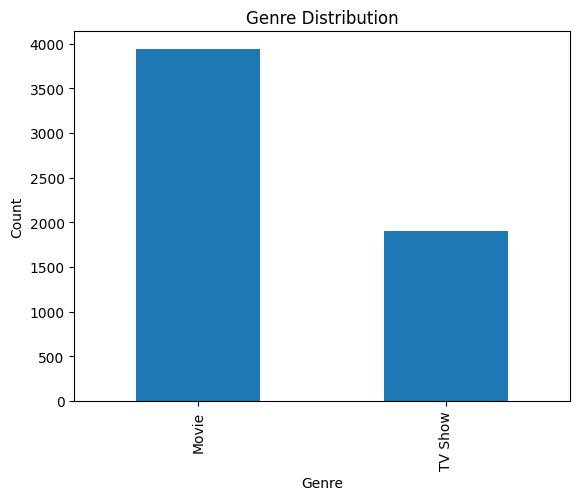

In [43]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

## Top Countries

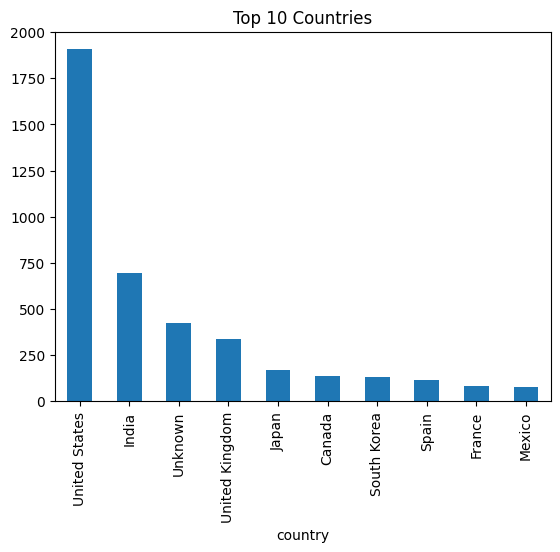

In [44]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

Release Year Trend

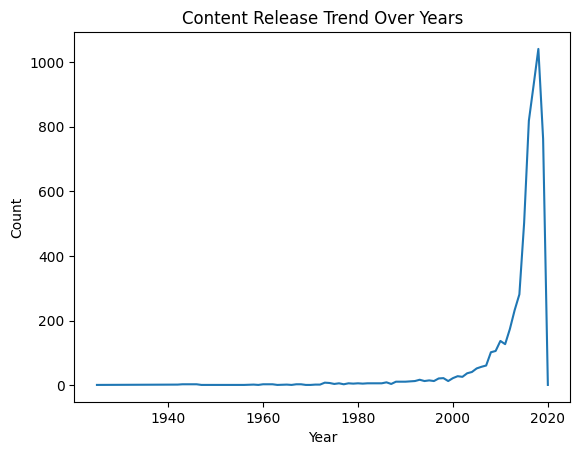

In [45]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## Feature Engineering

In [46]:
df['combined'] = (
    df['type'] + " " +
    df['description'] + " " +
    df['cast'] + " " +
    df['director'] + " " +
    df['country'] + " " +
    df['rating']
)

In [47]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['combined'] = df['combined'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ansht\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2), 
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df['combined'])

## PCA

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X.toarray())

## Silhouette Score

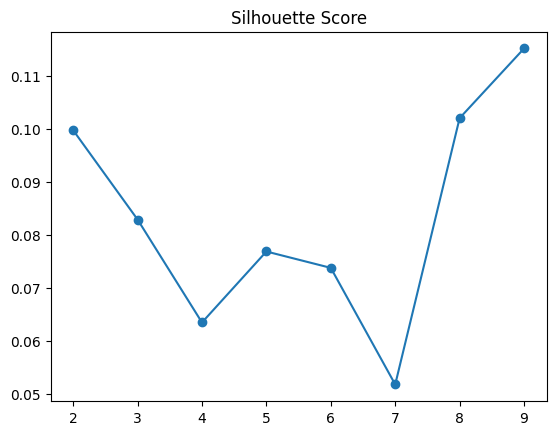

In [50]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

import matplotlib.pyplot as plt
plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score")
plt.show()

## Final model 

In [51]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_pca)

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

In [54]:
import pickle

pickle.dump(X, open("tfidf.pkl", "wb"))

In [58]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(tfidf_matrix)

import pickle
pickle.dump(similarity, open("similarity.pkl", "wb"))

In [ ]:
def recommend(title):
    idx = df[df['Title'] == title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    
    top = scores[1:6]
    
    for i in top:
        print(df.iloc[i[0]]['Title'])

In [ ]:
import numpy as np

terms = tfidf.get_feature_names_out()

for i in range(5):
    center = kmeans.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-10:]]
    
    print(f"\nCluster {i} Keywords:")
    print(top_words)


Cluster 0 Keywords:
['aaron paul', 'account', 'abigail', 'accounts', 'accident', 'abad', 'abbas', 'abandoned', 'abbas alibhai', 'aamir']

Cluster 1 Keywords:
['abbas alibhai', 'abu', 'abigail', 'abbas', 'abhishek bachchan', 'abdel', 'abdullah', 'abel', 'abdel aziz', 'abdulfattah']

Cluster 2 Keywords:
['action', 'abbas alibhai', 'abby', 'abby trott', 'abbas', 'aaron paul', 'abad', 'aaron', 'aamir', 'aamir khan']

Cluster 3 Keywords:
['abuse', 'abusive', 'abe', 'abbas alibhai', 'abducted', 'abbas', 'aamir bashir', 'aaron paul', 'abad', 'abandoned']

Cluster 4 Keywords:
['actionpacked', 'access', 'abdel aziz', 'abhay', 'abd', 'abroad', 'abdel', 'aamir bashir', 'abby', 'aamir']


In [ ]:
import pickle

pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))

df.to_csv("clustered_netflijupyter nbconvert --to script your_notebook.ipynbx.csv", index=False)

In [ ]:
import streamlit as st
import pandas as pd
import pickle

df = pd.read_csv("clustered_netflix.csv")

st.title("🎬 Netflix Recommendation System")

# Show selection
show = st.selectbox("Choose a show", df['title'])

# Recommend
if st.button("Recommend"):
    cluster = df[df['Title']==show]['cluster'].values[0]
    
    recs = df[df['cluster']==cluster]['Title'].head(10)
    
    st.write("### Similar Shows:")
    for r in recs:
        st.write(r)

2026-04-18 20:45:21.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:21.906 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:21.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:21.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:22.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:22.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:22.260 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 20:45:22.269 Session state does not function when running a script without `streamlit run`
2026-04-18 20:45